# Edge-Ready ECG Classification using CRISP-DM

## Setup

In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import wfdb

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MITDB = PROJECT_ROOT / "data" / "mit-bih-arrhythmia-database-1.0.0"
RESULTS = PROJECT_ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

assert MITDB.is_dir(), f"database folder not found: {MITDB}"
assert (MITDB / "100.dat").exists(), f"no records inside {MITDB}"

# Record split, DS1 is development,  DS2 is final test set.
DS1 = [
    "101",
    "106",
    "108",
    "109",
    "112",
    "114",
    "115",
    "116",
    "118",
    "119",
    "122",
    "124",
    "201",
    "203",
    "205",
    "207",
    "208",
    "209",
    "215",
    "220",
    "223",
    "230",
]

DS2 = [
    "100",
    "103",
    "105",
    "111",
    "113",
    "117",
    "121",
    "123",
    "200",
    "202",
    "210",
    "212",
    "213",
    "214",
    "219",
    "221",
    "222",
    "228",
    "231",
    "232",
    "233",
    "234",
]

# Removed because nearly all of the beats are paced "/", and AAMI excludes paced beats
EXCLUDED_RECORDS = ["102", "104", "107", "217"]

# MIT-BIH is 48 records from 47 subjects: records 201 and 202 come from the
# same subject. Both are in the split, so 44 records come from 43 subjects
N_SUBJECTS = 43

# Symbols that mark an actual heartbeat
BEAT_SYMBOLS = {
    "N",
    "L",
    "R",
    "e",
    "j",
    "A",
    "a",
    "J",
    "S",
    "V",
    "E",
    "F",
    "/",
    "f",
    "Q",
}

# Symbols that mark an event in the signal but carry no heartbeat
NON_BEAT = {
    "+",
    "~",
    "|",
    "!",
    "[",
    "]",
    "x",
    '"',
    "s",
    "T",
    "*",
    "D",
    "=",
    "p",
    "^",
    "t",
    "u",
    "?",
    "(",
    ")",
    "@",
}

# AAMI EC57 grouping. Some of the 15 beat types occur only a 
# handful of times, so the standard collapses them into 5 groups
AAMI_MAP = {
    "N": "N",  # Normal beat
    "L": "N",  # Left bundle branch block beat
    "R": "N",  # Right bundle branch block beat
    "e": "N",  # Atrial escape beat
    "j": "N",  # Nodal escape beat
    "A": "S",  # Atrial premature contraction
    "a": "S",  # Aberrated atrial premature beat
    "J": "S",  # Nodal premature beat
    "S": "S",  # Supraventricular premature or ectopic beat
    "V": "V",  # Premature ventricular contraction
    "E": "V",  # Ventricular escape beat
    "F": "F",  # Fusion of ventricular and normal beat
    "/": "Q",  # Paced beat
    "f": "Q",  # Fusion of paced and normal beat
    "Q": "Q",  # Unclassifiable beat
}

CLASSES = ["N", "S", "V", "F"]

# MLII is in nearly every record and shows the clearest beat shape, so we never mix leads between records
LEAD = "MLII"

print(f"Database: {MITDB}")
print(f"Records:  {len(DS1)} DS1 + {len(DS2)} DS2 = {len(DS1) + len(DS2)}")

Database: /Users/p4ffos/Projects/Study/LTU Projects (MSc)/Data_Mining/Group19_ECG_Project/data/mit-bih-arrhythmia-database-1.0.0
Records:  22 DS1 + 22 DS2 = 44


## 2.1 Dataset description

In [2]:
# One row per record, how it was recorded (rate, leads, length)
def collect_metadata(records, split_name):
    rows = []
    for record_id in records:
        header = wfdb.rdheader(str(MITDB / record_id))

        # Lead names can carry trailing spaces
        leads = [name.strip() for name in header.sig_name]

        rows.append(
            {
                "record": record_id,
                "split": split_name,
                "fs_hz": header.fs,
                "n_channels": header.n_sig,
                "n_samples": header.sig_len,
                "duration_min": round(header.sig_len / header.fs / 60, 2),
                "channel_0": leads[0],
                "channel_1": leads[1] if len(leads) > 1 else "",
                "units": "/".join(header.units),
            }
        )
    return rows


metadata = pd.DataFrame(collect_metadata(DS1, "DS1") + collect_metadata(DS2, "DS2"))
display(metadata)
metadata.to_csv(RESULTS / "record_metadata.csv", index=False)

,record,split,fs_hz,n_channels,n_samples,duration_min,channel_0,channel_1,units
0,101,DS1,360,2,650000,30.09,MLII,V1,mV/mV
1,106,DS1,360,2,650000,30.09,MLII,V1,mV/mV
2,108,DS1,360,2,650000,30.09,MLII,V1,mV/mV
3,109,DS1,360,2,650000,30.09,MLII,V1,mV/mV
4,112,DS1,360,2,650000,30.09,MLII,V1,mV/mV
5,114,DS1,360,2,650000,30.09,V5,MLII,mV/mV
6,115,DS1,360,2,650000,30.09,MLII,V1,mV/mV
7,116,DS1,360,2,650000,30.09,MLII,V1,mV/mV
8,118,DS1,360,2,650000,30.09,MLII,V1,mV/mV
9,119,DS1,360,2,650000,30.09,MLII,V1,mV/mV


In [3]:
print("Database: MIT-BIH Arrhythmia Database v1.0.0 (PhysioNet)")
print("Number of records: " + str(len(metadata)) + " of 48")
print("Records dropped: " + ", ".join(EXCLUDED_RECORDS))
print("Number of subjects: " + str(N_SUBJECTS) + " (records 201 and 202 share a subject)")
print("Number of channels: " + str(metadata["n_channels"].unique()))
print("Sampling frequency: " + str(metadata["fs_hz"].unique()) + " Hz")

total_minutes = metadata["duration_min"].sum()
print(f"Recording duration: {total_minutes:.0f} min in total")
print("Annotation type: beat-by-beat")

Database: MIT-BIH Arrhythmia Database v1.0.0 (PhysioNet)
Number of records: 44 of 48
Records dropped: 102, 104, 107, 217
Number of subjects: 43 (records 201 and 202 share a subject)
Number of channels: [2]
Sampling frequency: [360] Hz
Recording duration: 1324 min in total
Annotation type: beat-by-beat


In [4]:
# ECG leads available
print("ECG leads available:")
lead_pairs = metadata.groupby(["channel_0", "channel_1"]).size()
print(lead_pairs)

# Which records have MLII, and in which channel position
in_channel_0 = []
in_channel_1 = []
missing_lead = []

for i in range(len(metadata)):
    row = metadata.iloc[i]
    if row["channel_0"] == LEAD:
        in_channel_0.append(row["record"])
    elif row["channel_1"] == LEAD:
        in_channel_1.append(row["record"])
    else:
        missing_lead.append(row["record"])

print(f"\n{LEAD} in channel 0: {len(in_channel_0)} records")
print(f"{LEAD} in channel 1: {len(in_channel_1)} records {in_channel_1}")
print(f"{LEAD} not present: {len(missing_lead)} records {missing_lead}")

ECG leads available:
channel_0  channel_1
MLII       V1           38
           V2            2
           V4            1
           V5            2
V5         MLII          1
dtype: int64

MLII in channel 0: 43 records
MLII in channel 1: 1 records ['114']
MLII not present: 0 records []


## 2.2 Target classes

In [5]:
# One row per record and symbol: how often that label appears in that record.
# Counting per record, not only per database, lets us check later whether a
# rare class comes from just one or two patients
def collect_counts(records, split_name):
    rows = []
    for record_id in records:
        annotation = wfdb.rdann(str(MITDB / record_id), "atr")
        counts = Counter(annotation.symbol)

        for symbol, count in counts.items():
            # Stop on an unexpected label instead of mislabelling beats
            if symbol not in BEAT_SYMBOLS and symbol not in NON_BEAT:
                raise ValueError(f"Unknown symbol {symbol!r} in record {record_id}")
            rows.append(
                {
                    "split": split_name,
                    "record": record_id,
                    "symbol": symbol,
                    "count": count,
                    "is_beat": symbol in BEAT_SYMBOLS,
                    # non-beat markers have no AAMI class, hence the "-" default
                    "aami_class": AAMI_MAP.get(symbol, "-"),
                }
            )
    return rows


df = pd.DataFrame(collect_counts(DS1, "DS1") + collect_counts(DS2, "DS2"))

display(df.head())
print("Rows:", len(df))
print("Records:", df["record"].nunique())
print("Total annotations:", df["count"].sum())
print("Beats:", df.loc[df["is_beat"], "count"].sum())
print("Markers:", df.loc[~df["is_beat"], "count"].sum())
print("Distinct symbols:", sorted(df["symbol"].unique()))

,split,record,symbol,count,is_beat,aami_class
0,DS1,101,+,1,False,-
1,DS1,101,N,1860,True,N
2,DS1,101,~,4,False,-
3,DS1,101,|,4,False,-
4,DS1,101,Q,2,True,Q


Rows: 260
Records: 44
Total annotations: 103724
Beats: 100733
Markers: 2991
Distinct symbols: ['!', '"', '+', 'A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', '[', ']', 'a', 'e', 'j', 'x', '|', '~']


In [6]:
# Total annotations of one split inside any subset of the table
def total_count(frame, split_name):
    return int(frame.loc[frame["split"] == split_name, "count"].sum())


# Table A: every raw annotation symbol, records added up
rows = []
for symbol in sorted(df["symbol"].unique()):
    subset = df[df["symbol"] == symbol]
    ds1 = total_count(subset, "DS1")
    ds2 = total_count(subset, "DS2")
    rows.append(
        {
            "symbol": symbol,
            "is_beat": bool(subset["is_beat"].iloc[0]),
            "aami_class": subset["aami_class"].iloc[0],
            "DS1": ds1,
            "DS2": ds2,
            "total": ds1 + ds2,
        }
    )

symbol_table = pd.DataFrame(rows)
# real beats first, then most frequent first
symbol_table = symbol_table.sort_values(["is_beat", "total"], ascending=[False, False])

display(symbol_table)
symbol_table.to_csv(RESULTS / "symbol_counts.csv", index=False)

,symbol,is_beat,aami_class,DS1,DS2,total
8,N,True,N,38102,36444,74546
7,L,True,N,3949,4126,8075
10,R,True,N,3783,3476,7259
12,V,True,V,3683,3220,6903
3,A,True,S,810,1736,2546
5,F,True,F,415,388,803
17,j,True,N,16,213,229
15,a,True,S,100,50,150
4,E,True,V,105,1,106
6,J,True,S,32,51,83


In [7]:
# Table B: the four target classes
beats = df[df["is_beat"]]

# Beats we keep per split (N + S + V + F, no Q)
ds1_kept = 0
ds2_kept = 0
for class_name in CLASSES:
    class_rows = beats[beats["aami_class"] == class_name]
    ds1_kept = ds1_kept + total_count(class_rows, "DS1")
    ds2_kept = ds2_kept + total_count(class_rows, "DS2")

# One row per class. Q is shown for transparency but gets no percentage, because it is not part of the kept beats
rows = []
for class_name in CLASSES + ["Q"]:
    class_rows = beats[beats["aami_class"] == class_name]
    ds1 = total_count(class_rows, "DS1")
    ds2 = total_count(class_rows, "DS2")
    symbols_present = sorted(class_rows["symbol"].unique())
    rows.append(
        {
            "class": class_name,
            "annotations_included": ", ".join(symbols_present),
            "DS1": ds1,
            "DS2": ds2,
            "total": ds1 + ds2,
            "% DS1": round(100 * ds1 / ds1_kept, 2) if class_name in CLASSES else None,
            "% DS2": round(100 * ds2 / ds2_kept, 2) if class_name in CLASSES else None,
        }
    )

class_table = pd.DataFrame(rows)

display(class_table)
class_table.to_csv(RESULTS / "class_counts.csv", index=False)

print(f"Beats kept: DS1={ds1_kept}  DS2={ds2_kept}")

# Annotations excluded from the four target classes
excluded_symbols = ["/", "f", "Q", "!"]

print("Excluded annotations:")
for symbol in excluded_symbols:
    n = int(df.loc[df["symbol"] == symbol, "count"].sum())
    print(f"  {symbol}: {n} annotations")

print(f"\nPaced records not in DS1/DS2: {', '.join(EXCLUDED_RECORDS)}")

,class,annotations_included,DS1,DS2,total,% DS1,% DS2
0,N,"L, N, R, e, j",45866,44259,90125,89.91,89.04
1,S,"A, J, S, a",944,1837,2781,1.85,3.70
2,V,"E, V",3788,3221,7009,7.43,6.48
3,F,F,415,388,803,0.81,0.78
4,Q,Q,8,7,15,NaN,NaN


Beats kept: DS1=51013  DS2=49705
Excluded annotations:
  /: 0 annotations
  f: 0 annotations
  Q: 15 annotations
  !: 472 annotations

Paced records not in DS1/DS2: 102, 104, 107, 217


## 2.3 Exploratory Data Analysis

In [8]:
# Helper functions

HALF_WIDTH = 100

def get_one_record(record_id):
    record = wfdb.rdrecord(str(MITDB / record_id))
    fs = record.fs
    lead_names = [name.strip() for name in record.sig_name]
    
    if LEAD not in lead_names:
        raise ValueError(f"Record {record_id} has no MLII; leads are {lead_names}")

    channel_index = lead_names.index(LEAD)
    signal = record.p_signal[:, channel_index]

    return (signal, fs)

def one_record_beats(record_id):
    rows = []
    annotation = wfdb.rdann(str(MITDB / record_id), "atr")
    
    for symbol, sample in zip(annotation.symbol, annotation.sample):
        if symbol in BEAT_SYMBOLS:
            rows.append(
                {
                    "sample": sample,
                    "symbol": symbol,
                    "aami_class": AAMI_MAP[symbol],
                }
            )
    return pd.DataFrame(rows)

def context_window(signal, center, half_width):
    start = center - half_width
    end = center + half_width
    if start < 0 or end > len(signal):
        return None
    return signal[start:end]

### 2.3.1 Plot one example signal from the dataset

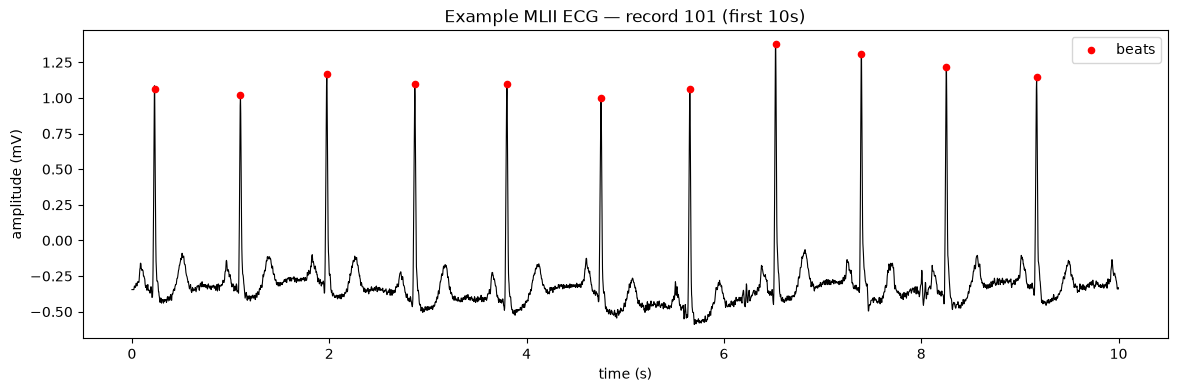

In [9]:
def plot_example_signal(record_id, seconds):
    signal, fs = get_one_record(record_id)

    n = int(fs * seconds)
    strip = signal[:n]
    t = np.arange(n) / fs

    beats_here = one_record_beats(record_id)
    beats_here = beats_here[beats_here["sample"] < n]
    beat_times = beats_here["sample"].to_numpy() / fs
    beat_amps = strip[beats_here["sample"].to_numpy()]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, strip, linewidth=0.8, color="black")
    ax.scatter(beat_times, beat_amps, color="red", s=20, zorder=3, label="beats")

    ax.set_title(f"Example MLII ECG — record {record_id} (first {seconds}s)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("amplitude (mV)")
    ax.legend()
    plt.show()

plot_example_signal("101", seconds=10)

### 2.3.2 Example beat from each class

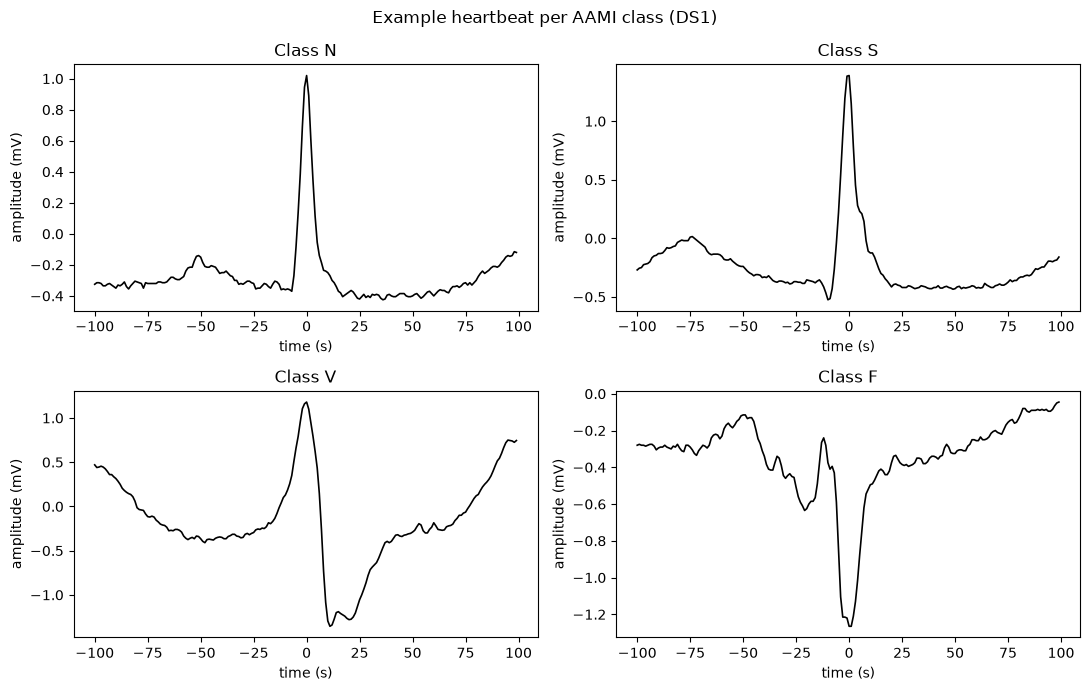

In [10]:
def plot_beat_per_class(records=DS1):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    t = (np.arange(2 * HALF_WIDTH) - HALF_WIDTH)

    for ax, cls in zip(axes.flat, CLASSES):
        example = None
        for record_id in records:
            signal, fs = get_one_record(record_id)
            hits = one_record_beats(record_id)
            hits = hits[hits["aami_class"] == cls]
            for pos in hits["sample"].to_numpy():
                w = context_window(signal, int(pos), HALF_WIDTH)
                if w is not None:
                    example = w
                    break
            if example is not None:
                break

        if example is None:
            ax.set_title(f"Class {cls}: none found")
            continue
        ax.plot(t, example, color="black", linewidth=1.2)
        ax.set_title(f"Class {cls}")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("amplitude (mV)")

    fig.suptitle("Example heartbeat per AAMI class (DS1)")
    plt.tight_layout()
    plt.show()
    
plot_beat_per_class(DS1)

### 2.3.3 Plot class distribution for each split in the dataset

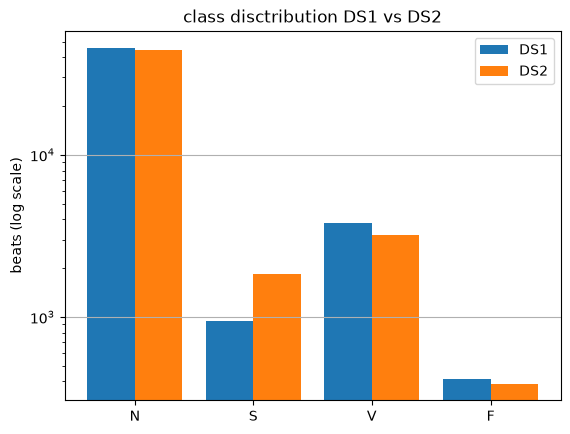

In [11]:
def plot_class_distribution(beats):
    ds1_heights = []
    ds2_heights = []
    
    for class_name in CLASSES:
        class_rows = beats[beats["aami_class"] == class_name]
        ds1 = total_count(class_rows, "DS1")
        ds2 = total_count(class_rows, "DS2")
        ds1_heights.append(ds1)
        ds2_heights.append(ds2)

    
    fig, ax = plt.subplots()
    x = np.arange(len(CLASSES))
    width = 0.40
    
    ax.bar(x - width/2, ds1_heights, width, label='DS1')
    ax.bar(x + width/2, ds2_heights, width, label='DS2')
    ax.set_xticks(x, CLASSES)
    ax.set_yscale('log', base=10)
    ax.set_ylabel('beats (log scale)')
    ax.set(title='class disctribution DS1 vs DS2')
    ax.legend()
    ax.yaxis.grid()

plot_class_distribution(beats)

### 2.3.4 Plot record distribution in the DS1 split

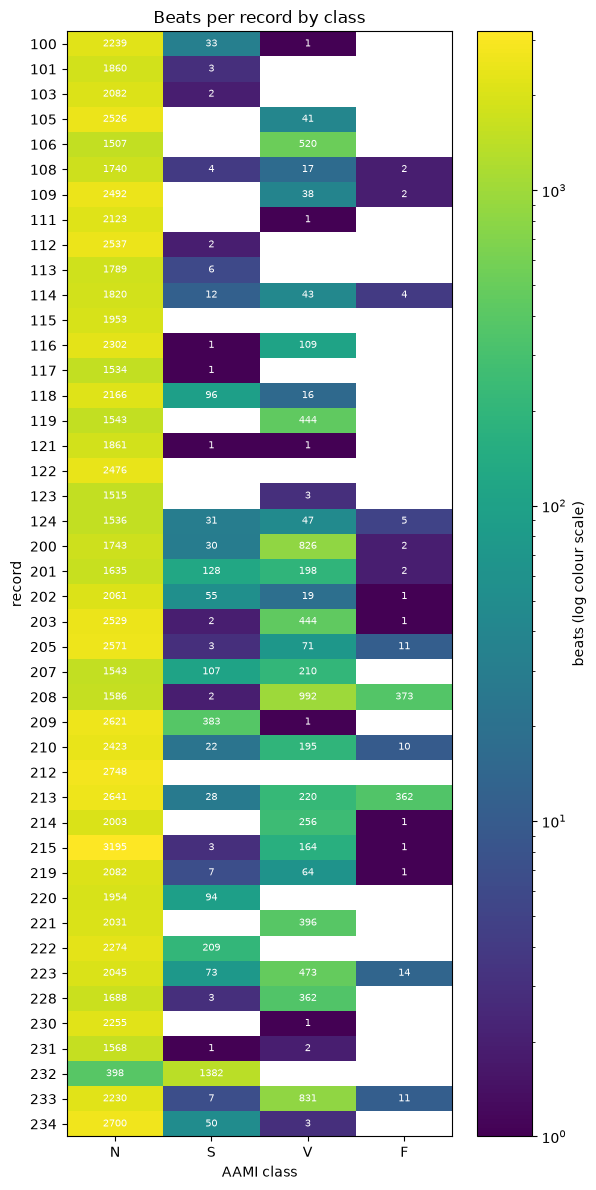

In [12]:
def plot_record_distribution(beats):
    table = (beats.groupby(["record", "aami_class"])["count"].sum().unstack("aami_class").fillna(0))
    table = table[CLASSES].astype(int)
    records = table.index.tolist()
    classes = table.columns.tolist()
    values = table.values 

    fig, ax = plt.subplots(figsize=(6, 12))
    im = ax.imshow(
        values,
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(vmin=1, vmax=values.max()),
    )

    for i in range(len(records)):
        for j in range(len(classes)):
            ax.text(j, i, values[i, j],
                    ha="center", va="center", color="white", fontsize=7)

    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticks(range(len(records)))
    ax.set_yticklabels(records)
    
    fig.colorbar(im, ax=ax, label="beats (log colour scale)")
    ax.set_title("Beats per record by class")
    ax.set_xlabel("AAMI class")
    ax.set_ylabel("record")
    plt.tight_layout()
    plt.show()

plot_record_distribution(beats)

### 2.3.5 Plot signal amplitude distribution in the DS1 split

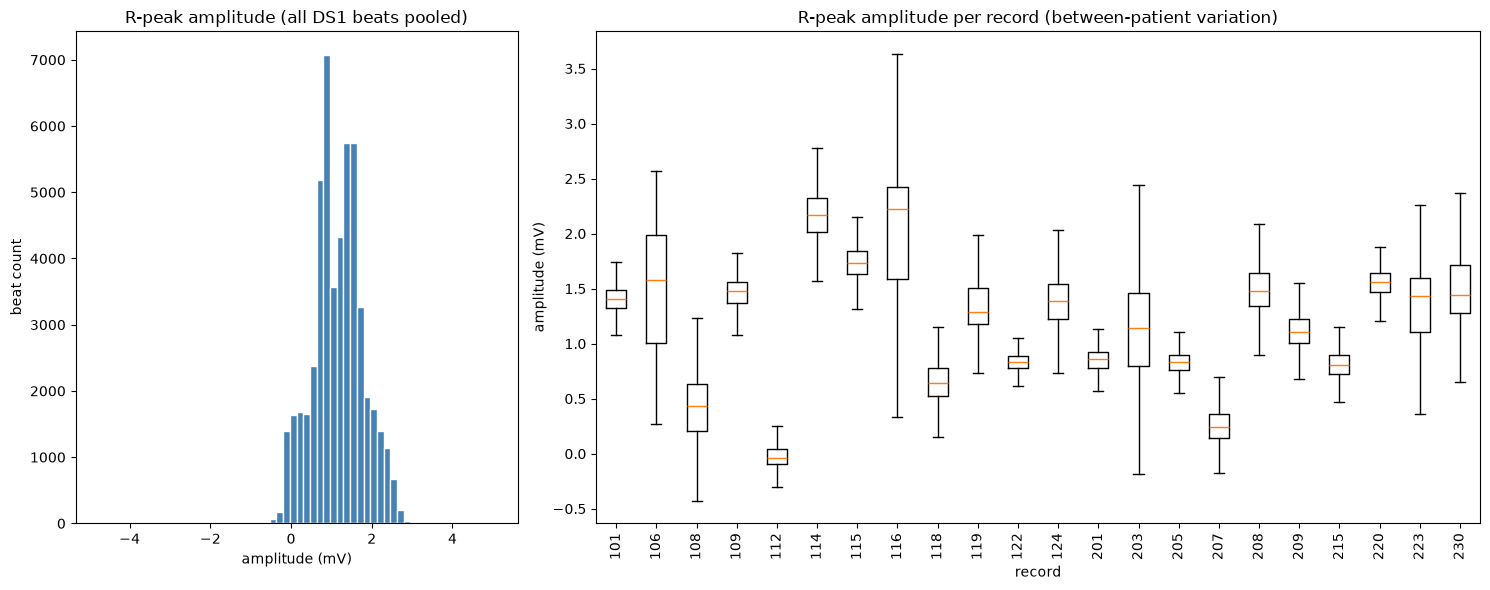

In [13]:
def plot_amplitude_distribution(records=DS1):
    per_record = {}
    
    for record_id in records:
        signal, fs = get_one_record(record_id)
        beats = one_record_beats(record_id)
        amps = []
        for pos in beats["sample"].to_numpy():
            w = context_window(signal, int(pos), HALF_WIDTH)
            if w is not None:
                amps.append(float(np.max(w)))
        per_record[record_id] = amps

    all_amps = np.concatenate([np.array(v) for v in per_record.values() if v])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6),
                                   gridspec_kw={"width_ratios": [1, 2]})
    ax1.hist(all_amps, bins=60, color="steelblue", edgecolor="white")
    ax1.set_title("R-peak amplitude (all DS1 beats pooled)")
    ax1.set_xlabel("amplitude (mV)")
    ax1.set_ylabel("beat count")

    labels = list(per_record.keys())
    data = [per_record[r] for r in labels]
    ax2.boxplot(data, tick_labels=labels, showfliers=False)
    ax2.set_title("R-peak amplitude per record (between-patient variation)")
    ax2.set_xlabel("record")
    ax2.set_ylabel("amplitude (mV)")
    ax2.tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

plot_amplitude_distribution(DS1)

### 2.3.6 Plot example of a clean signal vs example of a noisy signal samples 

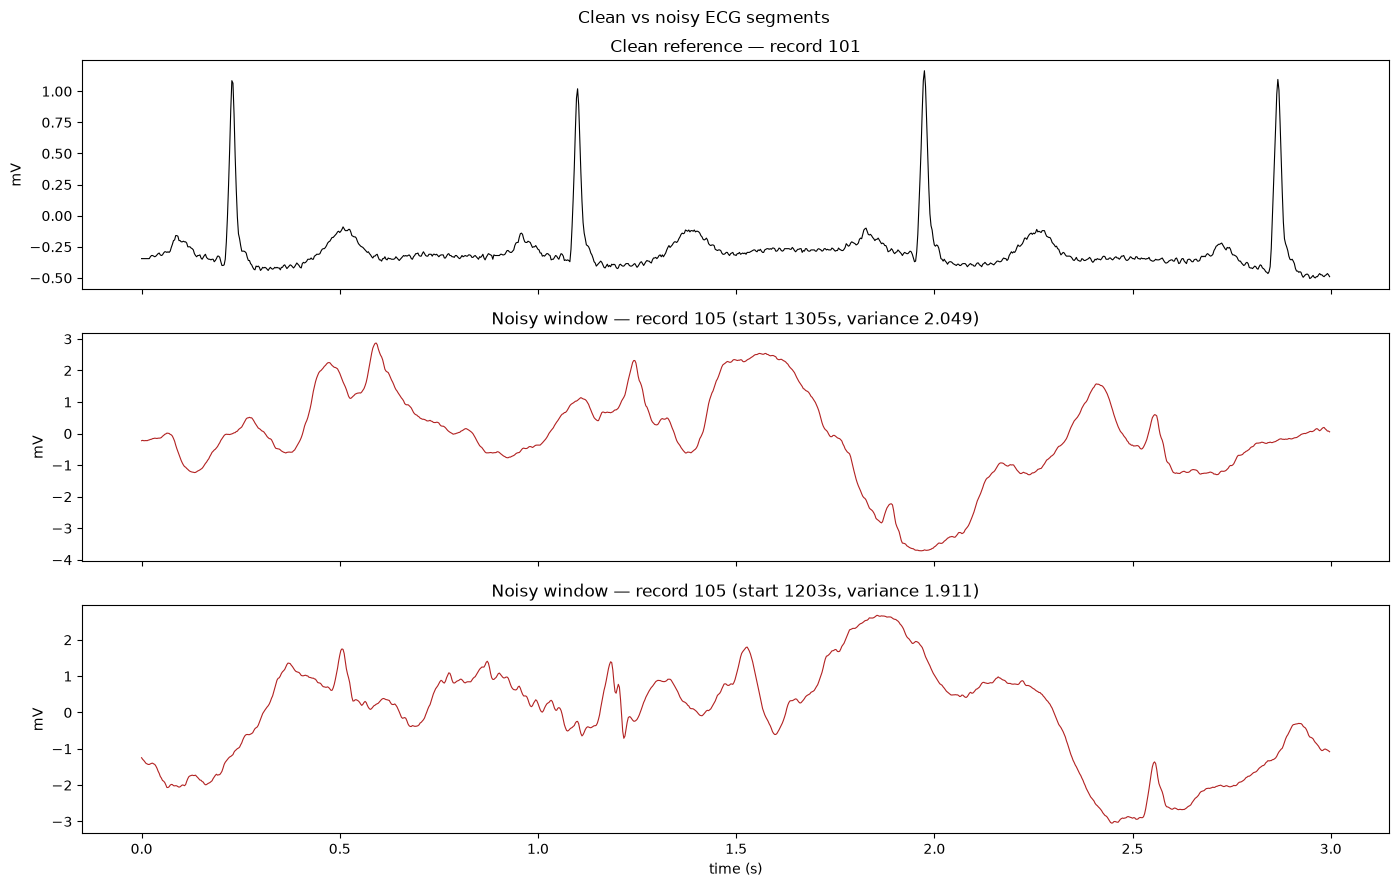

In [14]:
def find_noisy_windows(record_id, window_sec, top_k):
    signal, fs = get_one_record(record_id)
    win = int(fs * window_sec)
    scored = []
    for start in range(0, len(signal) - win, win):
        seg = signal[start:start + win]
        scored.append((np.var(seg), start))
    scored.sort(reverse=True)
    return signal, fs, scored[:top_k]

def plot_noisy_examples(noisy_record="105", clean_record="101", window_sec=3):
    # Clean reference
    clean_sig, clean_fs = get_one_record(clean_record)
    cwin = int(clean_fs * window_sec)
    clean_seg = clean_sig[:cwin]
    ct = np.arange(cwin) / clean_fs

    # Two noisy windows from a record known for artefacts
    nsig, nfs, noisy = find_noisy_windows(noisy_record, window_sec, 2)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(ct, clean_seg, color="black", linewidth=0.8)
    axes[0].set_title(f"Clean reference — record {clean_record}")
    axes[0].set_ylabel("mV")

    for ax, (var, start) in zip(axes[1:], noisy):
        seg = nsig[start:start + int(nfs * window_sec)]
        tt = np.arange(len(seg)) / nfs
        ax.plot(tt, seg, color="firebrick", linewidth=0.8)
        ax.set_title(f"Noisy window — record {noisy_record} "
                     f"(start {start/nfs:.0f}s, variance {var:.3f})")
        ax.set_ylabel("mV")

    axes[-1].set_xlabel("time (s)")
    fig.suptitle("Clean vs noisy ECG segments")
    plt.tight_layout()
    plt.show()

plot_noisy_examples("105", "101")

## 2.4 Data Quality

In [15]:
# Class imbalance. Normal beats are about 90% of all beats, so answering "N"
# every time would already score ~90% accuracy while catching no arrhythmia at all
counts = {}
for class_name in CLASSES:
    class_rows = beats[beats["aami_class"] == class_name]
    counts[class_name] = int(class_rows["count"].sum())

total_beats = sum(counts.values())

print("Class imbalance:")
for class_name in CLASSES:
    share = 100 * counts[class_name] / total_beats
    ratio = counts["N"] / counts[class_name]
    print(
        f"  {class_name}: {counts[class_name]:>6} beats  {share:5.2f}%  "
        f"(1 {class_name} per {ratio:.0f} N)"
    )

# How many records contain each class
n_records = len(DS1) + len(DS2)
print("\nHow many records contain each class:")
for class_name in CLASSES:
    class_rows = beats[beats["aami_class"] == class_name]
    per_record = class_rows.groupby("record")["count"].sum()
    top3 = per_record.nlargest(3)
    share = 100 * top3.sum() / counts[class_name]
    print(
        f"  {class_name}: {len(per_record)} of {n_records} records, "
        f"top 3 hold {share:.0f}% ({list(top3.index)})"
    )

Class imbalance:
  N:  90125 beats  89.48%  (1 N per 1 N)
  S:   2781 beats   2.76%  (1 S per 32 N)
  V:   7009 beats   6.96%  (1 V per 13 N)
  F:    803 beats   0.80%  (1 F per 112 N)

How many records contain each class:
  N: 44 of 44 records, top 3 hold 10% (['215', '212', '234'])
  S: 32 of 44 records, top 3 hold 71% (['232', '209', '222'])
  V: 33 of 44 records, top 3 hold 38% (['208', '233', '200'])
  F: 17 of 44 records, top 3 hold 93% (['208', '213', '223'])


In [16]:
# 10 s = 3600 samples at 360 Hz
WINDOW_SECONDS = 10


# One row per record with numbers that expose the usual raw-ECG problems
def collect_signal_quality(records, split_name):
    rows = []
    for record_id in records:
        # rdrecord loads the full waveform (~30 min), so this cell is slow
        record = wfdb.rdrecord(str(MITDB / record_id))
        lead_names = [name.strip() for name in record.sig_name]

        # Select the lead by NAME
        channel_index = lead_names.index(LEAD)
        # p_signal is a (samples, channels) array in mV
        signal = record.p_signal[:, channel_index]

        # Drop NaN, or one bad sample turns every statistic into NaN
        is_valid = np.isfinite(signal)
        signal = signal[is_valid]

        # Split into windows and compare the worst one against the typical one
        window_size = WINDOW_SECONDS * record.fs
        n_windows = len(signal) // window_size
        windows = signal[: n_windows * window_size].reshape(n_windows, window_size)
        window_std = windows.std(axis=1)

        low = float(np.percentile(signal, 0.1))
        high = float(np.percentile(signal, 99.9))
        
        record = wfdb.rdrecord(str(MITDB / record_id), physical=False)
        digital = record.d_signal[:, channel_index]
        clipped = int(((digital <= 0) | (digital >= 2047)).sum())

        rows.append(
            {
                "record": record_id,
                "split": split_name,
                "missing_samples": int((~is_valid).sum()),
                "amplitude_min_mV": round(float(signal.min()), 3),
                "amplitude_max_mV": round(float(signal.max()), 3),
                # 99.9th minus 0.1st percentile: the range the signal
                # actually occupies, ignoring isolated spikes
                "typical_range_mV": round(high - low, 3),
                "amplitude_std_mV": round(float(signal.std()), 3),
                # worst window over the median window: ~1 is an evenly clean
                # record, a large value means one stretch is far noisier
                "disturbance_ratio": round(
                    float(window_std.max()) / float(np.median(window_std)), 2
                ),
                # MIT-BIH is 11-bit over about +/-5.11 mV. Samples at that
                # limit mean the amplifier saturated and the peak was cut off.
                "clipped_samples": clipped,
            }
        )
    return rows


signal_quality = pd.DataFrame(
    collect_signal_quality(DS1, "DS1") + collect_signal_quality(DS2, "DS2")
)

display(signal_quality)
signal_quality.to_csv(RESULTS / "signal_quality.csv", index=False)

,record,split,missing_samples,amplitude_min_mV,amplitude_max_mV,typical_range_mV,amplitude_std_mV,disturbance_ratio,clipped_samples
0,101,DS1,0,-3.175,2.420,2.550,0.261,3.73,0
1,106,DS1,0,-2.065,2.570,3.475,0.368,1.44,0
2,108,DS1,0,-3.035,2.365,3.970,0.301,4.91,0
3,109,DS1,0,-3.195,3.130,4.060,0.499,2.09,0
4,112,DS1,0,-2.635,0.820,1.880,0.224,2.52,0
5,114,DS1,0,-2.505,3.770,4.040,0.375,3.10,0
6,115,DS1,0,-2.885,2.410,3.740,0.363,2.35,0
7,116,DS1,0,-5.120,5.115,8.270,0.664,4.23,928
8,118,DS1,0,-3.090,2.395,3.345,0.428,2.29,0
9,119,DS1,0,-2.985,2.500,4.610,0.535,1.43,0


In [17]:
# missing data
print(
    "Missing data:",
    int((signal_quality["missing_samples"] > 0).sum()),
    "of",
    len(signal_quality),
)

# differences between recordings. The same beat is several times "louder" in
# one record than in another, which is the argument for normalising per record
std_min = signal_quality["amplitude_std_mV"].min()
std_max = signal_quality["amplitude_std_mV"].max()
print(
    f"\nAmplitude: {std_min:.3f} to {std_max:.3f} mV "
    f"({std_max / std_min:.1f}x spread between records)"
)

# extreme amplitudes, min/max far outside typical_range means isolated spikes
print("\nWidest signals:")
display(signal_quality.nlargest(5, "typical_range_mV"))

# possible noisy regions
print("\nMost disturbed records:")
display(signal_quality.nlargest(5, "disturbance_ratio"))
print("Calmest records:")
display(signal_quality.nsmallest(5, "disturbance_ratio"))

# Differences between ECG channels, each lead has its own amplitude, and 114
# stores them the other way round, so the lead has to be picked by name
for record_id in ["100", "103", "105", "114"]:
    record = wfdb.rdrecord(str(MITDB / record_id))
    names = [name.strip() for name in record.sig_name]
    print(
        f"{record_id}: {names[0]} std {record.p_signal[:, 0].std():.3f}, "
        f"{names[1]} std {record.p_signal[:, 1].std():.3f}"
    )

# Corrupted segments. A clipped stretch cannot be repaired, the true peak is
# gone, so it can only be excluded or accepted
print("\nRecords that hit the +/-5.11 mV limit:")
clipped = signal_quality[signal_quality["clipped_samples"] > 0]
if len(clipped) == 0:
    print("  none")
else:
    display(clipped[["record", "split", "clipped_samples"]])

Missing data: 0 of 44

Amplitude: 0.165 to 0.671 mV (4.1x spread between records)

Widest signals:


,record,split,missing_samples,amplitude_min_mV,amplitude_max_mV,typical_range_mV,amplitude_std_mV,disturbance_ratio,clipped_samples
7,116,DS1,0,-5.120,5.115,8.270,0.664,4.23,928
13,203,DS1,0,-4.305,3.640,4.835,0.495,2.52,0
34,213,DS2,0,-2.530,3.285,4.700,0.671,1.38,0
24,105,DS2,0,-3.715,3.000,4.650,0.405,3.43,0
9,119,DS1,0,-2.985,2.500,4.610,0.535,1.43,0



Most disturbed records:


,record,split,missing_samples,amplitude_min_mV,amplitude_max_mV,typical_range_mV,amplitude_std_mV,disturbance_ratio,clipped_samples
28,121,DS2,0,-4.450,1.400,3.38,0.301,5.86,0
2,108,DS1,0,-3.035,2.365,3.97,0.301,4.91,0
25,111,DS2,0,-2.820,2.375,2.45,0.257,4.88,0
7,116,DS1,0,-5.120,5.115,8.27,0.664,4.23,928
15,207,DS1,0,-3.955,2.285,3.47,0.354,3.78,0


Calmest records:


,record,split,missing_samples,amplitude_min_mV,amplitude_max_mV,typical_range_mV,amplitude_std_mV,disturbance_ratio,clipped_samples
18,215,DS1,0,-1.380,2.500,2.855,0.282,1.24,0
37,221,DS2,0,-1.390,2.230,2.495,0.301,1.30,0
35,214,DS2,0,-2.730,2.800,4.300,0.470,1.33,0
40,231,DS2,0,-1.355,2.050,2.725,0.272,1.33,0
17,209,DS1,0,-1.455,1.885,2.340,0.268,1.34,0


100: MLII std 0.193, V5 std 0.148
103: MLII std 0.322, V2 std 0.687
105: MLII std 0.405, V1 std 0.279
114: V5 std 0.171, MLII std 0.375

Records that hit the +/-5.11 mV limit:


,record,split,clipped_samples
7,116,DS1,928


## 3.1 Record Selection

In [18]:
ds1 = (beats[beats["split"] == "DS1"]
       .groupby(["record", "aami_class"])["count"].sum()
       .unstack("aami_class").reindex(columns=CLASSES).fillna(0).astype(int))
ds1["total"] = ds1.sum(axis=1)
print(ds1.sort_values("F", ascending=False).to_string())

aami_class     N    S    V    F  total
record                                
208         1586    2  992  373   2953
223         2045   73  473   14   2605
205         2571    3   71   11   2656
124         1536   31   47    5   1619
114         1820   12   43    4   1879
108         1740    4   17    2   1763
109         2492    0   38    2   2532
201         1635  128  198    2   1963
203         2529    2  444    1   2976
215         3195    3  164    1   3363
220         1954   94    0    0   2048
209         2621  383    1    0   3005
207         1543  107  210    0   1860
101         1860    3    0    0   1863
106         1507    0  520    0   2027
122         2476    0    0    0   2476
119         1543    0  444    0   1987
118         2166   96   16    0   2278
116         2302    1  109    0   2412
115         1953    0    0    0   1953
112         2537    2    0    0   2539
230         2255    0    1    0   2256
